# 🚢 Titanic Data Visualization Dashboard
## Data Science with Python Internship — Task 4
**Author:** Rahul Prajapat 


**Dataset:** Titanic Passenger Dataset  
**Libraries:** pandas, numpy, matplotlib, seaborn

---
## 1. Overview
This notebook presents a mini visualization dashboard exploring the Titanic dataset.  
We will clean the data, engineer useful features, and produce **5+ distinct charts** to uncover patterns in passenger survival.

---
## 2. Import Libraries & Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Apply seaborn theme
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (9, 5)

print('Libraries loaded successfully ✅')

Libraries loaded successfully ✅


---
## 3. Load the Dataset

In [2]:
df = pd.read_csv('Titanic-Dataset.csv')

print('Shape:', df.shape)
print('\nColumn Info:')
print(df.info())
print('\nFirst 5 rows:')
df.head()

Shape: (891, 12)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---
## 4. Data Cleaning

In [3]:
print('Missing values before cleaning:')
print(df.isnull().sum())

# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin if present (too many nulls)
df = df.drop(columns=['Cabin'], errors='ignore')

print('\nMissing values after cleaning:')
print(df.isnull().sum())
print('\nData cleaned successfully ✅')

Missing values before cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Data cleaned successfully ✅


---
## 5. Feature Engineering

In [4]:
# Feature 1: FamilySize = SibSp + Parch
df['FamilySize'] = df['SibSp'] + df['Parch']

# Feature 2: AgeGroup — categorize age into meaningful bins
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 30, 50, 80],
    labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
)

print('New features created:')
print(df[['Age', 'AgeGroup', 'SibSp', 'Parch', 'FamilySize']].head(8))

New features created:
    Age     AgeGroup  SibSp  Parch  FamilySize
0  22.0  Young Adult      1      0           1
1  38.0        Adult      1      0           1
2  26.0  Young Adult      0      0           0
3  35.0        Adult      1      0           1
4  35.0        Adult      0      0           0
5  28.0  Young Adult      0      0           0
6  54.0       Senior      0      0           0
7   2.0        Child      3      1           4


---
## 6. Visualizations

### 📊 Chart 1 — Age Distribution (Histogram)

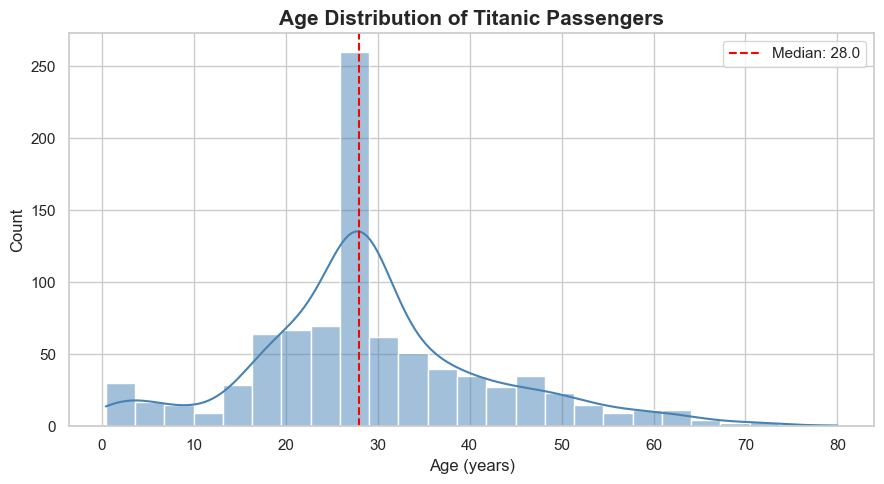

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df['Age'], bins=25, kde=True, color='steelblue', ax=ax)
ax.set_title('Age Distribution of Titanic Passengers', fontsize=15, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.axvline(df['Age'].median(), color='red', linestyle='--', linewidth=1.5, label=f"Median: {df['Age'].median():.1f}")
ax.legend()
plt.tight_layout()
plt.savefig('images/chart1_age_distribution.png', bbox_inches='tight')
plt.show()

**📝 Insight:** The majority of passengers were between 20–40 years old, with the median age around 28. The distribution is right-skewed, indicating fewer elderly passengers on board.

---
### 📊 Chart 2 — Survival Rate by Gender (Bar Chart)

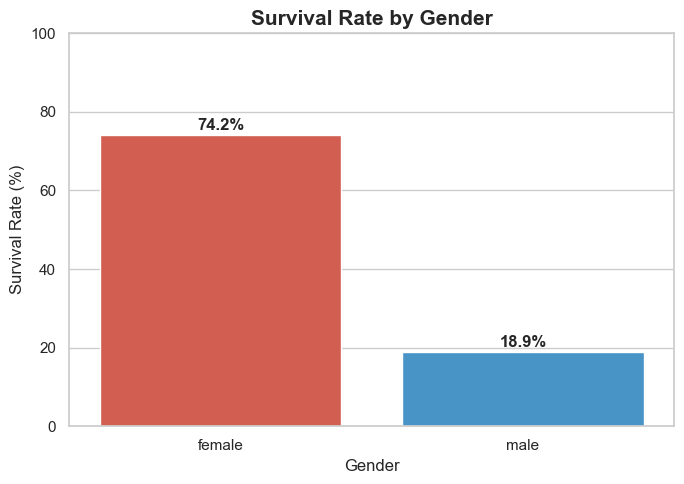

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
survival_by_sex = df.groupby('Sex')['Survived'].mean().reset_index()
survival_by_sex['Survived'] = survival_by_sex['Survived'] * 100

bars = sns.barplot(x='Sex', y='Survived', data=survival_by_sex,
                   palette=['#e74c3c', '#3498db'], ax=ax)

for bar in bars.patches:
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
              f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Survival Rate by Gender', fontsize=15, fontweight='bold')
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Survival Rate (%)', fontsize=12)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('images/chart2_survival_by_gender.png', bbox_inches='tight')
plt.show()

**📝 Insight:** Females had a dramatically higher survival rate (~74%) compared to males (~19%), strongly reflecting the "women and children first" evacuation policy during the disaster.

---
### 📊 Chart 3 — Survival Rate by Passenger Class (Bar Chart)

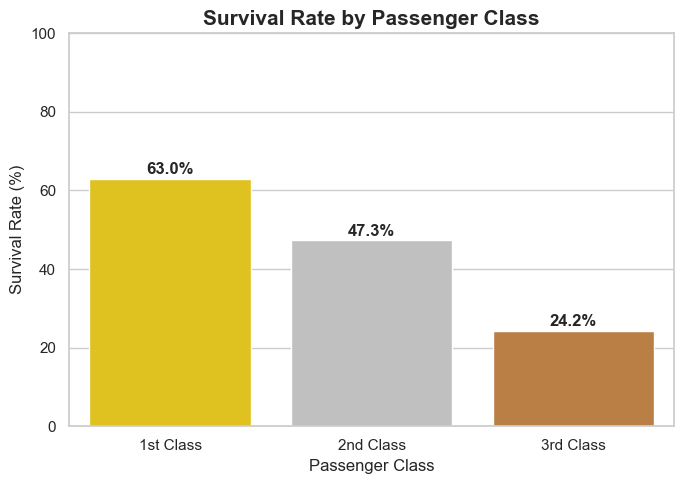

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
survival_by_class = df.groupby('Pclass')['Survived'].mean().reset_index()
survival_by_class['Survived'] = survival_by_class['Survived'] * 100
survival_by_class['Pclass'] = survival_by_class['Pclass'].map({1: '1st Class', 2: '2nd Class', 3: '3rd Class'})

bars2 = sns.barplot(x='Pclass', y='Survived', data=survival_by_class,
                    palette=['gold', 'silver', '#cd7f32'], ax=ax)

for bar in bars2.patches:
    bars2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
               f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Survival Rate by Passenger Class', fontsize=15, fontweight='bold')
ax.set_xlabel('Passenger Class', fontsize=12)
ax.set_ylabel('Survival Rate (%)', fontsize=12)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('images/chart3_survival_by_class.png', bbox_inches='tight')
plt.show()

**📝 Insight:** First-class passengers had the highest survival rate, nearly double that of third-class passengers. This reveals a clear socioeconomic bias in survival — wealthier passengers had better access to lifeboats.

---
### 📊 Chart 4 — Fare Distribution by Class (Boxplot)

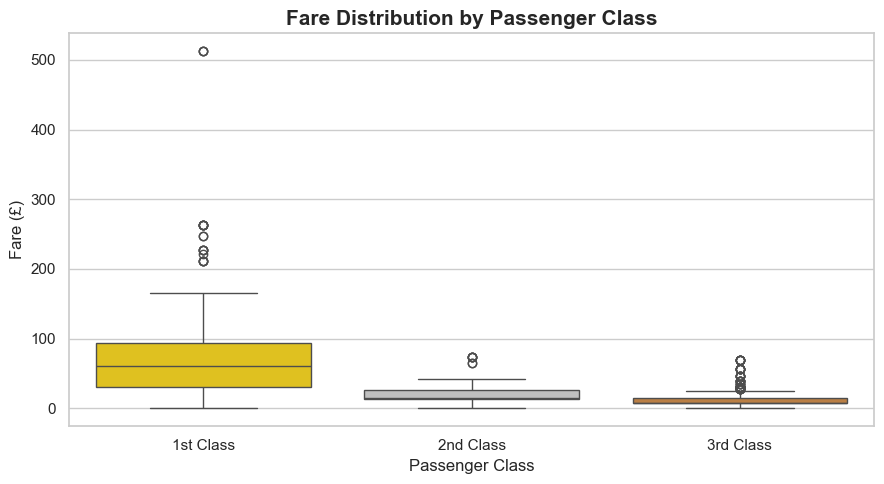

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
df_box = df.copy()
df_box['Class'] = df_box['Pclass'].map({1: '1st Class', 2: '2nd Class', 3: '3rd Class'})

sns.boxplot(x='Class', y='Fare', data=df_box,
            order=['1st Class', '2nd Class', '3rd Class'],
            palette=['gold', 'silver', '#cd7f32'], ax=ax)

ax.set_title('Fare Distribution by Passenger Class', fontsize=15, fontweight='bold')
ax.set_xlabel('Passenger Class', fontsize=12)
ax.set_ylabel('Fare (£)', fontsize=12)
plt.tight_layout()
plt.savefig('images/chart4_fare_by_class.png', bbox_inches='tight')
plt.show()

**📝 Insight:** First-class tickets had significantly higher median fares with a wide spread and many outliers, indicating luxury pricing variation. Third-class fares were tightly clustered at the lower end with minimal variation.

---
### 📊 Chart 5 — Age vs. Fare colored by Survival (Scatterplot)

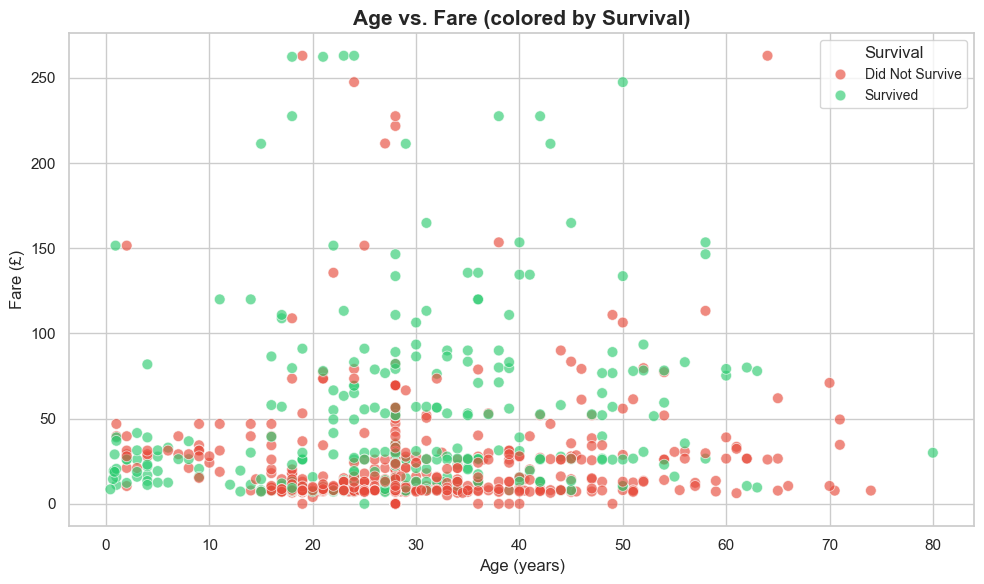

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = sns.scatterplot(
    x='Age', y='Fare',
    hue='Survived',
    data=df[df['Fare'] < 300],  # exclude extreme outliers for clarity
    palette={0: '#e74c3c', 1: '#2ecc71'},
    alpha=0.65, s=60, ax=ax
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Did Not Survive', 'Survived'], title='Survival', fontsize=10)
ax.set_title('Age vs. Fare (colored by Survival)', fontsize=15, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Fare (£)', fontsize=12)
plt.tight_layout()
plt.savefig('images/chart5_age_vs_fare.png', bbox_inches='tight')
plt.show()

**📝 Insight:** Passengers who paid higher fares (upper portion of the chart) show a higher proportion of survivors (green), further confirming that class/wealth played a key role in survival. Age alone does not clearly separate survivors from non-survivors.

---
### 📊 Chart 6 — Survival Rate by Age Group (Bar Chart)

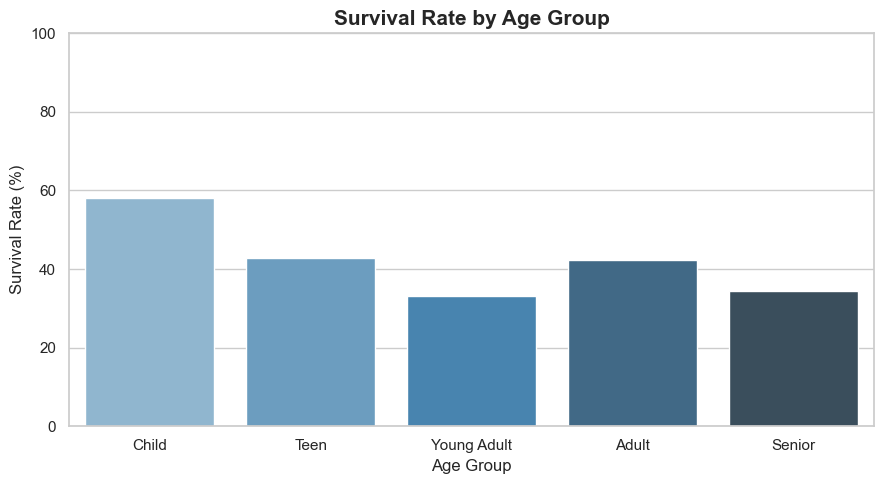

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
age_survival = df.groupby('AgeGroup', observed=True)['Survived'].mean().reset_index()
age_survival['Survived'] = age_survival['Survived'] * 100

sns.barplot(x='AgeGroup', y='Survived', data=age_survival,
            palette='Blues_d', ax=ax)

ax.set_title('Survival Rate by Age Group', fontsize=15, fontweight='bold')
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Survival Rate (%)', fontsize=12)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('images/chart6_survival_by_agegroup.png', bbox_inches='tight')
plt.show()

**📝 Insight:** Children had the highest survival rate among all age groups, supporting the "children first" evacuation principle. Survival rates gradually declined for older age groups.

---
### 📊 Chart 7 — Correlation Heatmap

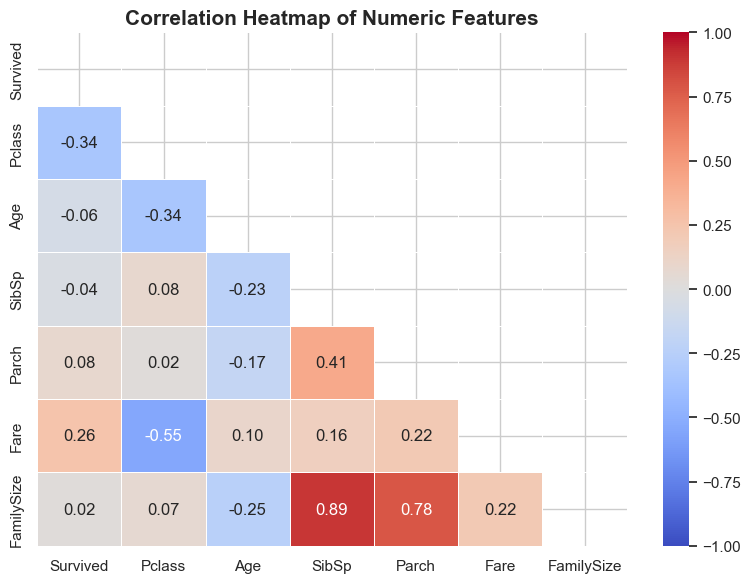

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
numeric_cols = df.select_dtypes(include='number').drop(columns=['PassengerId'], errors='ignore')
corr_matrix = numeric_cols.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5, ax=ax)

ax.set_title('Correlation Heatmap of Numeric Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('images/chart7_correlation_heatmap.png', bbox_inches='tight')
plt.show()

**📝 Insight:** `Pclass` has a moderate negative correlation with `Fare` (lower class = lower fare) and a negative correlation with `Survived`. `FamilySize` shows a slight positive correlation with `SibSp` and `Parch`, as expected from its definition.

---
### 📊 Bonus — Survival by Class and Gender (Facet Catplot)

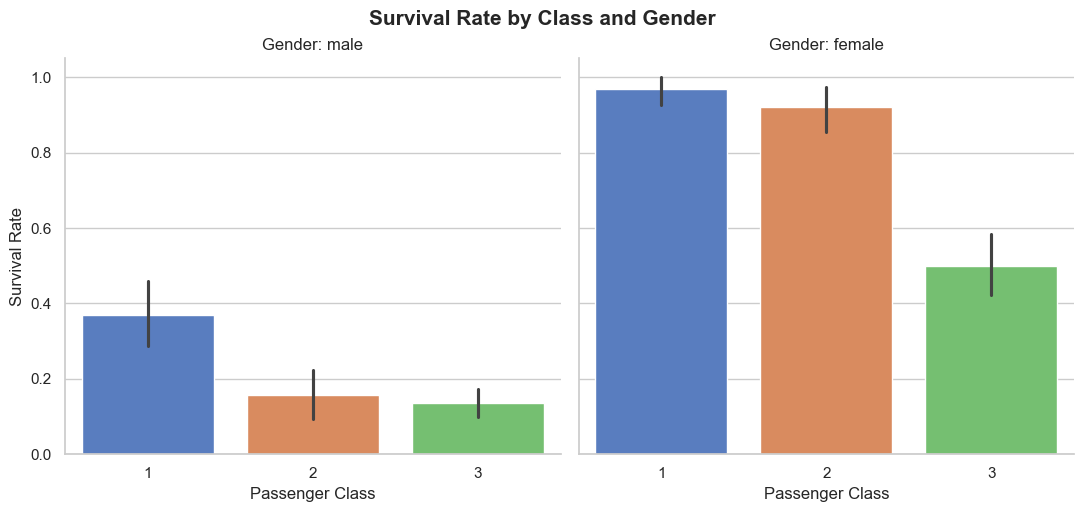

In [12]:
g = sns.catplot(
    col='Sex', x='Pclass', y='Survived',
    kind='bar', data=df,
    palette='muted', height=5, aspect=1.1,
    order=[1, 2, 3]
)
g.set_axis_labels('Passenger Class', 'Survival Rate')
g.set_titles(col_template='Gender: {col_name}')
g.figure.suptitle('Survival Rate by Class and Gender', fontsize=15, fontweight='bold', y=1.02)
g.figure.savefig('images/bonus_class_gender.png', bbox_inches='tight')
plt.show()

**📝 Insight:** Across all classes, females consistently outsurvived males. The gender gap is especially stark in 3rd class, where female survival was notably higher despite the overall lower class survival rate.

---
## 7. Key Insights Summary

| Finding | Detail |
|---|---|
| **Gender** | Females survived at ~74% vs. ~19% for males |
| **Class** | 1st class passengers had the highest survival rate |
| **Age** | Children had the best survival odds among all age groups |
| **Fare** | Higher fares strongly correlated with higher survival |
| **Age distribution** | Most passengers were 20–40 years old |
| **Pclass & Fare** | Strong negative correlation — class 1 paid the most |

---
## 8. Conclusion

This dashboard reveals that **survival on the Titanic was heavily influenced by gender, passenger class, and wealth** (fare paid). The "women and children first" protocol is clearly visible in the data. Socioeconomic status (Pclass + Fare) was the second strongest predictor of survival. 

These insights form a strong foundation for building a predictive machine learning model (e.g., Logistic Regression or Random Forest) in future tasks.